In [6]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene'

In [1]:
import sys, os

print(os.getpid())

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

def add_path(p: str):
    if p not in sys.path:
        sys.path.append(p)

add_path(os.environ['LP_ROOT'])
add_path(os.environ['PROJECT'])

import project

import torch
assert torch.cuda.is_available()

1054943


# Gather examples

In [2]:
from pathlib import Path

#data_root = Path(os.environ['LP_ROOT']) / 'data' / 'COPDGene'
data_root = Path(os.environ['PRIVATE']) / 'data' / 'COPDGene'

subject_file = data_root / 'sample1000_2025-07-22.csv'
subject_list = project.fileio.load_subject_list(subject_file, key='sid', sep='\t')

data_config = {
    'name': 'COPDGene',
    'root': str(data_root),
    'subjects': subject_list[:1],
    'state_pairs': [('EXP', 'INSP')],
    'variant': 'TEST',
    'pipeline_tags': {
        'image_segmentation':  'v0',
        'material_properties': 'v3',
        'mesh_generation':     'v2',
        'forward_simulation':  'debug'
    }
}

examples = project.get_examples(data_config)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/sample1000_2025-07-22.csv
Gathering examples...
1 total


# Run optimization

In [17]:
import math

opt_config = {
    'parameters': {'E': {'mode': 'log10', 'v_loc': 2e3, 'v_min': 0, 'v_max': 2e4}},
    'pde_solver': {
        'type': 'warp.fem',
        'material_type': 'linear',
        'g_vector': (0, -9.81, 0),
        'relative_loss': True,
        'tv_reg_weight': 1e-4,
        'verbose': True
    },
    'boundary_condition': {'type': 'mesh_key', 'value': 'u_fwd'},
    'optimization_kws': {
        'type': 'LBFGS',
        'num_trials': 1,
        'init_scale': 0,
        'global_steps': 10,
        'local_steps': 100,
        'rtol': 1e-5,
        'max_iter': 1,
        'max_eval': 20,
        'line_search_fn': 'strong_wolfe'
    },
    'output_name': 'optimize'
}
True

True

In [ ]:
%autoreload
project.run_optimize(examples, opt_config)

[Example 0/1] Optimizing example: 16514P
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v2_v3_int_debug.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3_label.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz
Start optimization trial 1 / 1
Initializing parameters
Optimizing global mean(s)
[step 0] loss = 2.3606e-04 (delta = nan)
  grad_norm = 8.89073744e-07
[step 1] loss = 2.3606e-04 (delta = 0.0000e+00)
Optimization converged in 1 step(s)
Optimizing local values
[step 0] loss = 2.3606e-04 (delta = nan)
  grad_norm = 6.93106686e-05
  gra

In [10]:
ex = examples[0]

def load_E(ex, run_name=None):
    from project.common.outputs import Outputs
    if run_name is None:
        E_path = ex.paths['material_dir'] / 'youngs_modulus.nii.gz'
    else:
        E_path = Outputs(run_name).raster_dir(ex) / 'E_pred.nii.gz'
    return project.fileio.load_nibabel(E_path).get_fdata()

E_true = load_E(ex)
m = E_true > 1.0

E_pred = load_E(ex, 'optimize')

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3/youngs_modulus.nii.gz
Loading outputs/optimize/16514P/rasters/E_pred.nii.gz


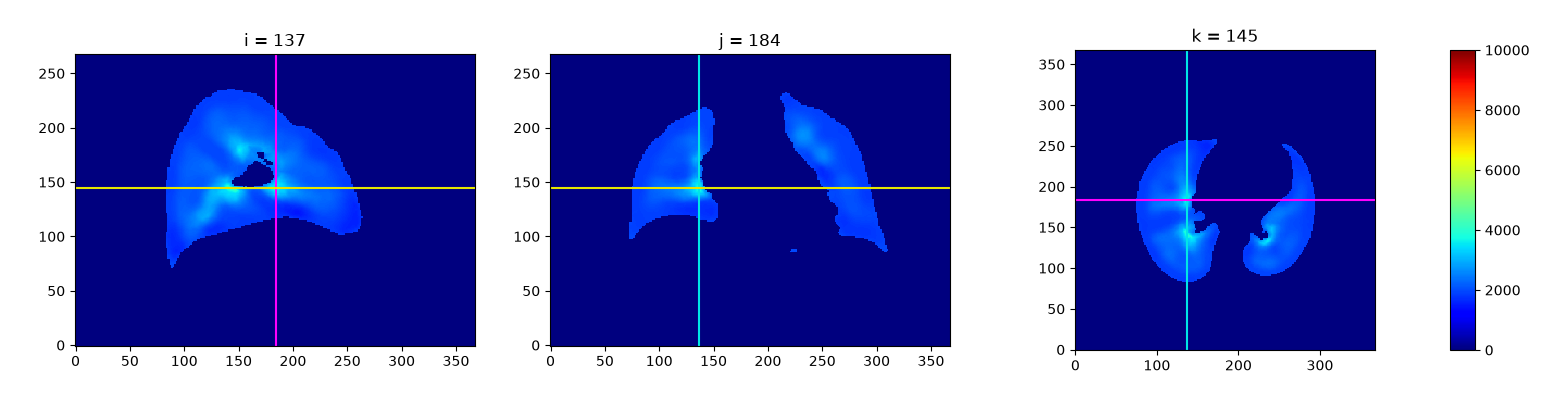

In [11]:
def view_E(E, **kwargs):
    import project.visual.matplotlib as mpl_viz
    kwargs.setdefault('ax_height', 3)
    kwargs.setdefault('ax_width', 4)
    kwargs.setdefault('index', (137, 184, 145))
    kwargs.setdefault('line_color', 'cmy')
    kwargs.setdefault('cmap', 'jet')
    kwargs.setdefault('vmin', 0)
    kwargs.setdefault('vmax', 1e4)
    return mpl_viz.SliceViewer(E, **kwargs)

view_E(E_pred * m)

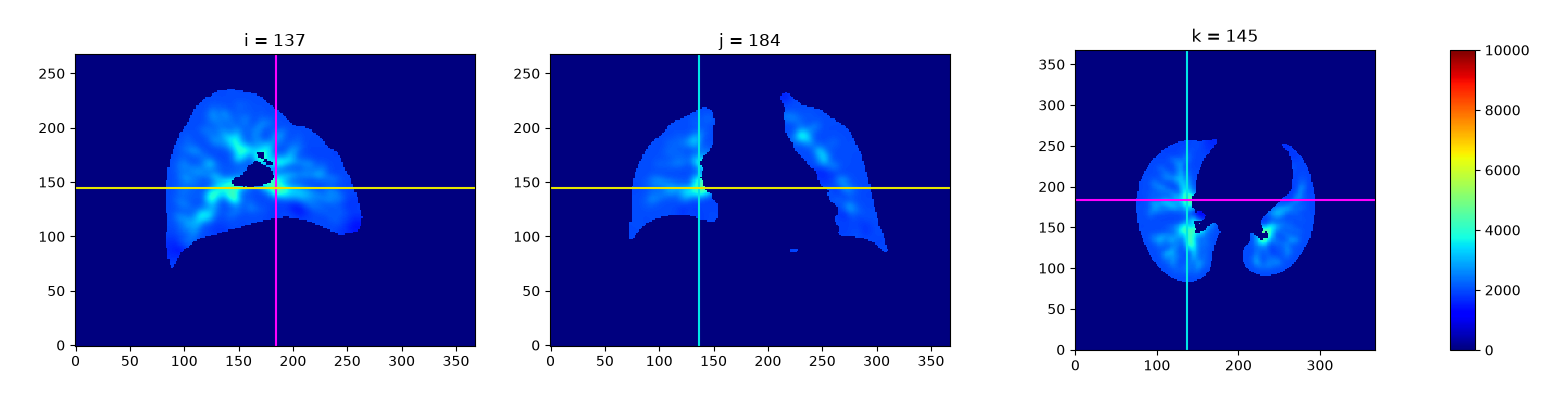

In [33]:
view_E(E_true * m)

/scratch/7632284.1.ece/ipykernel_1043379/406892338.py:1: RuntimeWarning: divide by zero encountered in log10
  view_E(np.log10(E_pred / E_true) * m, cmap='seismic', vmin=-1.0, vmax=1.0)
/scratch/7632284.1.ece/ipykernel_1043379/406892338.py:1: RuntimeWarning: invalid value encountered in multiply
  view_E(np.log10(E_pred / E_true) * m, cmap='seismic', vmin=-1.0, vmax=1.0)


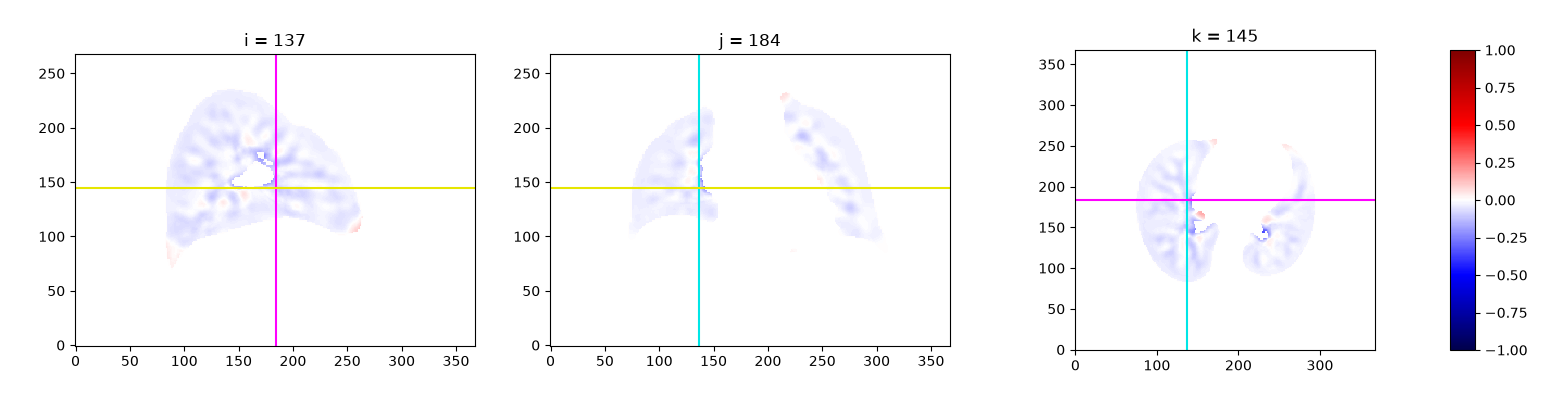

In [41]:
view_E(np.log10(E_pred / E_true) * m, cmap='seismic', vmin=-1.0, vmax=1.0)

# Gradient validation

In [16]:
def test_loss_path(ex, config, alphas):
    from project import core, datasets, physics, optimization
    import torch

    sample = datasets.api.load_example(ex)
    mesh = sample['mesh']
    unit_m = float(ex.metadata['unit'])

    solver = physics.get_solver(**config.get('pde_solver', {}))
    adapter = physics.get_adapter(solver, **config.get('physics_adapter', {}))
    bc_spec = physics.get_bc_spec(**config.get('boundary_condition', {}))

    template = adapter.initialize_scalar_field(mesh, unit_m)
    param_dict = optimization.ParameterDict(
        template, None, **config.get('parameters', {})
    )

    def objective(params):
        return adapter.mesh_simulation_loss(mesh, unit_m, params, bc_spec)[0]

    ctx = adapter.get_physics_context(mesh, unit_m)
    E_true = ctx.fields['E'][adapter.scalar_degree]

    z_true = param_dict.specs['E'].encode(E_true).cpu()
    z_init = param_dict._dofs['E'].detach().cpu().clone()

    loss_history = []
    for a in alphas:
        param_dict._dofs['E'] = (1 - a) * z_init + a * z_true  
        with torch.no_grad():
            loss = objective(param_dict(False)).item()
        loss_history.append(loss)

    return loss_history

alphas = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999, 1.0]
losses = test_loss_path(examples[0], opt_config, alphas)
list(zip(alphas, losses))

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v2_v3_int_LE.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3_label.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz


[(0.0, 0.0002360572398174554),
 (0.1, 0.00019008602248504758),
 (0.25, 0.00013112685701344162),
 (0.5, 5.8630641433410347e-05),
 (0.75, 1.679275737842545e-05),
 (0.9, 5.684724783350248e-06),
 (0.99, 3.8614375625911634e-06),
 (0.999, 3.874889443977736e-06),
 (1.0, 3.878563347825548e-06)]

Text(0, 0.5, 'loss')

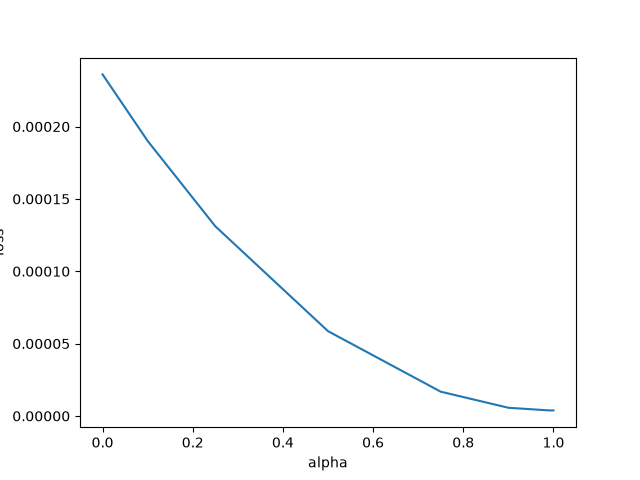

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(alphas, losses)
ax.set_xlabel('alpha')
ax.set_ylabel('loss')

In [25]:
def test_gradient(ex, config):
    from project import datasets, physics, optimization
    import torch

    sample = datasets.api.load_example(ex)
    mesh = sample['mesh']
    unit_m = float(ex.metadata['unit'])

    solver = physics.get_solver(**config.get('pde_solver', {}))
    adapter = physics.get_adapter(solver, **config.get('physics_adapter', {}))
    bc_spec = physics.get_bc_spec(**config.get('boundary_condition', {}))

    template = adapter.initialize_scalar_field(mesh, unit_m)
    param_dict = optimization.ParameterDict(
        template, None, **config.get('parameters', {})
    )

    def objective(params):
        return adapter.mesh_simulation_loss(mesh, unit_m, params, bc_spec)[0]

    ctx = adapter.get_physics_context(mesh, unit_m)
    E_true = ctx.fields['E'][adapter.scalar_degree]

    z_true = param_dict.specs['E'].encode(E_true).cuda()
    z_init = param_dict._dofs['E']

    loss = objective(param_dict(False))
    print('loss:', loss.item())

    loss.backward()
    grad = z_init.grad.detach()
    diff = z_true - z_init.detach()

    print(f'gradient norm: {torch.linalg.vector_norm(grad).item()}')
    print(f'true dir norm: {torch.linalg.vector_norm(diff).item()}')

    dot = torch.sum(grad * diff)
    cos = dot / (
        torch.linalg.vector_norm(grad) * torch.linalg.vector_norm(diff)
    )
    print(f'dot product: {dot.item()}')
    print(f'cosine: {cos.item()}')

    z_init = z_init.detach()

    def loss_at_alpha(alpha):
        with torch.no_grad():
            param_dict._dofs['E'] = z_init + alpha * diff
            return objective(param_dict()).item()

    for eps in [1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4]:
        loss_pos = loss_at_alpha(+eps)
        loss_neg = loss_at_alpha(-eps)
        fd_grad = (loss_pos - loss_neg) / (2 * eps)
        print(f'eps = {eps}  fd_grad = {fd_grad:.8f}  autograd = {dot.item():.8f}  ratio = {fd_grad / dot.item():.8f}')

    direction = -grad / torch.linalg.vector_norm(grad)
    
    def loss_at_step(step):
        with torch.no_grad():
            param_dict._dofs['E'] = z_init + z_init + step * direction
            return objective(param_dict()).item()

    for step in [0, 0.01, 0.03, 0.1, 0.3, 1.0, 3., 10., 30., 100.]:
        loss = loss_at_step(step)
        print(f'step = {step}  loss = {loss:.4f}')

test_gradient(examples[0], opt_config)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v2_v3_int_LE.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v3_label.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz
loss: 0.0002360572398174554
gradient norm: 2.310348099854309e-05
true dir norm: 38.416107177734375
dot product: -0.0004908527480438352
cosine: -0.5530449748039246
eps = 0.1  fd_grad = -0.00049102  autograd = -0.00049085  ratio = 1.00034304
eps = 0.03  fd_grad = -0.00049090  autograd = -0.00049085  ratio = 1.00010097
eps = 0.01  fd_grad = -0.00049090  autograd = -0.00049085  r

# Optimization experiments

In [34]:
import itertools, copy

base_config = {'dataset': data_config, 'optimize': opt_config}

errors = []
for fwd_mat, int_mat, spec_key in itertools.product(['LE'], ['LE'], ['log10']):
    config = copy.deepcopy(base_config)

    config['dataset']['subjects'] = ['16514P']
    config['dataset']['pipeline_tags']['forward_simulation'] = fwd_mat
    config['optimize']['pde_solver']['material_type'] = inv_mat
    config['optimize']['parameters']['E'] = param_specs[spec_key]
    config['optimize']['output_name'] = f'opt_{fwd_mat}_{inv_mat}_{spec_key}'

    examples = project.get_examples(config['dataset'])
    try:
        project.run_optimize(examples, config['optimize'])
    except Exception as e:
        project.utils.warn(f'FAILED: {e}')
        errors.append((fwd_mat, inv_mat, key, e))

errors

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tseg_corr_INSP_anat_pyg_mat_int_sim.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_tseg_mat_label.nii.gz
Targets: ['E']
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA A40" (44 GiB, sm_86, mempool enabled)
   Kernel cache:
     /usr2/collab/mragoza/.cache/warp/1.15.0
MeshField()
├── cell_values: Tensor(shape=torch.Size([98899, 3]), dtype=torch.float32, device=cpu)
|   ├── 0: Tensor(shape=torch.Size([3]), dtype=torch.float32, device=cpu)
|   ├── 1: Tensor(shape=torch.Size([3]), dtype=torch.float32, device=cpu)
| 

In [35]:
from project.common.outputs import Outputs

nifti = project.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
E_true = nifti.get_fdata()

E_pred_path = Outputs('opt_LE_LE_log10').raster_dir(ex) / 'E_pred.nii.gz'
E_pred = project.fileio.load_nibabel(E_pred_path).get_fdata()

index = (137, 184, 145)
spacing = (1., 1., 1.)

In [11]:
import project.visual.matplotlib as mpl_viz

E_kws = dict(cmap='jet', vmin=0, vmax=1e4)

mpl_viz.SliceViewer(E_pred, index=index, vox_spacing=spacing, ax_height=3, ax_width=4, line_color='cmy', **E_kws)

In [ ]:
mpl_viz.SliceViewer(E_pred, index=index, vox_spacing=spacing, ax_height=3, ax_width=4, line_color='cmy', **E_kws)

In [ ]:
mpl_viz.SliceViewer(E_true, index=index, vox_spacing=spacing, ax_height=3, ax_width=4, line_color='cmy', **E_kws)

In [ ]:
mpl_viz.SliceViewer(
    (E_pred - E_true) / E_true,
    index=index,
    vox_spacing=img0_spacing,
    ax_height=3,
    ax_width=4,
    cmap='seismic',
    clim=(-1.0, 1.0),
    line_color='cmy'
)

In [ ]:
rows = []
for i, tv_reg_weight in enumerate(tv_reg_weights):
    outputs = project.core.paths.RunOutputs(stage=f'opt_tv_reg_{i}')
    opt_mesh = project.core.fileio.load_meshio(outputs.mesh_path(ex, name='optimized'))

    u_true = opt_mesh.point_data['u_true']
    u_pred = opt_mesh.point_data['u_pred']

    u_rmse = project.core.metrics.absolute_rmse(u_pred, u_true)
    u_nrmse = project.core.metrics.normalized_rmse(u_pred, u_true)

    E_true, nu_true = project.core.transforms.E_nu_from_mu_lam(
        opt_mesh.point_data['mu_true'], opt_mesh.point_data['lam_true']
    )
    E_pred, nu_pred = project.core.transforms.E_nu_from_mu_lam(
        opt_mesh.point_data['mu_pred'], opt_mesh.point_data['lam_pred']
    )
    E_rmse = project.core.metrics.absolute_rmse(E_pred[:,None], E_true[:,None])
    E_nrmse = project.core.metrics.normalized_rmse(E_pred[:,None], E_true[:,None])

    rows.append([tv_reg_weight, u_rmse, u_nrmse, E_rmse, E_nrmse])

df = pd.DataFrame(rows, columns=['tv_reg_weight', 'u_rmse', 'u_nrmse', 'E_rmse', 'E_nrmse'])
df

In [ ]:
fig, axes = mpl_viz.subplot_grid(2, 2, ax_height=2, ax_width=3, padding=[1.0, 0.5, 1.0, 0.5], spacing=[0.75, 1.25])
axes = axes.flatten()

for i, y_col in enumerate(['u_rmse', 'E_rmse', 'u_nrmse', 'E_nrmse']):
    x_real = list(df.tv_reg_weight)
    x_dummy = [x if x > 0 else 1e-8 for x in x_real]
    axes[i].plot(x_dummy, df[y_col])
    axes[i].set_xlabel('TV_reg_weight')
    axes[i].set_ylabel(y_col)
    #axes[i].set_yscale('log')
    axes[i].set_xscale('log')
    axes[i].set_xticks(x_dummy)
    axes[i].set_xticklabels(x_real)


In [ ]:
def error_vs_boundary(mesh, bins):
    import numpy as np
    import pandas as pd
    import scipy.spatial

    cells = mesh.cells_dict['tetra']
    faces = np.vstack([
        cells[:, [0, 1, 2]],
        cells[:, [0, 1, 3]],
        cells[:, [0, 2, 3]],
        cells[:, [1, 2, 3]],
    ])
    faces = np.sort(faces, axis=1)
    faces, counts = np.unique(faces, axis=0, return_counts=True)
    boundary_nodes = np.unique(faces[counts == 1])

    tree = scipy.spatial.cKDTree(mesh.points[boundary_nodes])
    distance = tree.query(mesh.points)[0]

    def _E(mu, lam):
        return mu * (3 * lam + 2 * mu) / (lam + mu)

    E_true = _E(mesh.point_data['mu_true'], mesh.point_data['lam_true'])
    E_pred = _E(mesh.point_data['mu_pred'], mesh.point_data['lam_pred'])
    relative_error = (E_pred - E_true) / E_true

    df = pd.DataFrame({
        'distance': distance,
        'E_true': E_true,
        'E_pred': E_pred,
        'relative_error': relative_error,
        'abs_relative_error': np.abs(relative_error),
    })
    df['distance_bin'] = pd.cut(distance, bins=bins, include_lowest=True)

    summary = (
        df.groupby('distance_bin', observed=True)
        .agg(
            n=('relative_error', 'size'),
            mean_error=('relative_error', 'mean'),
            mean_abs_error=('abs_relative_error', 'mean'),
            median_error=('relative_error', 'median')
        ).reset_index()
    )
    return df, summary

df, summary = error_vs_boundary(opt_mesh, bins=[0, 2, 5, 10, 20, float('inf')])
summary

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df['distance'], df['relative_error'], s=1, alpha=0.05)
ax.set_xlabel('Distance from boundary')
ax.set_ylabel('Relative error')

# High-quality visualizations

In [13]:
ex = examples[1]
pprint(ex)

Example()
├── dataset:  'COPDGene'
├── subject:  '16514P'
├── variant:  '2026-08-08'
├── paths:    dict(len=13)
|   ├── 'ref_state':       dict(len=2)
|   ├── 'init_state':      dict(len=5)
|   ├── 'curr_state':      dict(len=5)
|   ├── 'anatomical_map':  PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_INSP_iso_tsvf_lung.nii.gz')
|   ├── 'anatomical_mesh': PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_INSP_iso_tsvf_lung_pyg.xdmf')
|   ├── 'material_map':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela_label.nii.gz')
|   ├── 'material_dir':    PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela')
|   ├── 'disp_field':      PosixPath('/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fie

In [14]:
img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
anat = project.core.fileio.load_nibabel(ex.paths['anatomical_map'])
m = anat.get_fdata() > 0

E = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

mesh = project.core.fileio.load_meshio(ex.paths['forward_mesh'])

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_INSP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/images/16514P_EXP_iso.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/masks/16514P_INSP_iso_tsvf_lung.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela/poisson_ratio.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/fields/16514P_INSP_iso_tsvf_bela/density.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-08-08/16514P/meshes/16514P_INSP_iso_tsvf_ugil_EXP_lung_pyg_bela_int_linear.xdmf


In [15]:
print(m.shape)
print(spacing0)
z = 134
c = 48

(368, 368, 268)
(-0.71875, 0.71875, 0.7000007629394531)


In [16]:
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

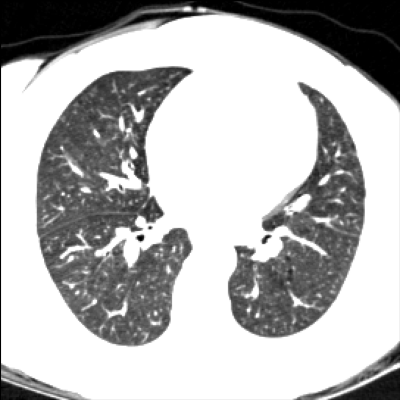

In [18]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img0.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

In [19]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img1.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

In [20]:
m = anat.get_fdata() > 0
E_m = E.get_fdata() * m
nu_m = nu.get_fdata() * m
rho_m = rho.get_fdata() * m

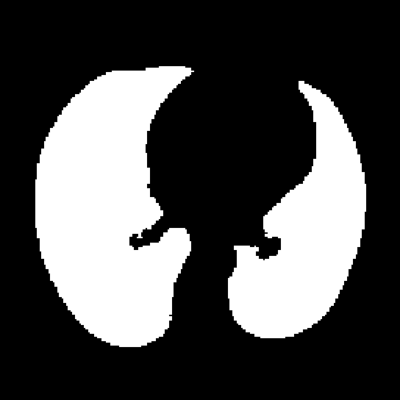

In [21]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(m[c:-c,c:-c,z].T, origin='lower', cmap='gray')

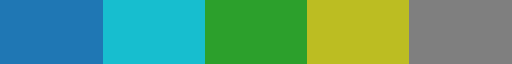

In [22]:
mpl_viz.get_label_cmap(5, include_bg=False)

In [23]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow((anat.get_fdata())[c:-c,c:-c,z].T, origin='lower', cmap=mpl_viz.get_label_cmap(5, include_bg=True))

In [24]:
import matplotlib.pyplot as plt

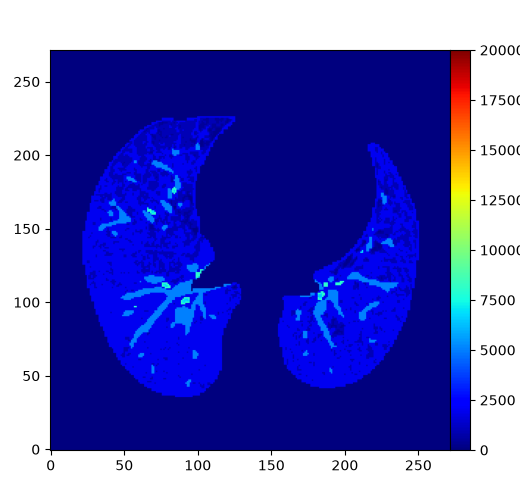

In [47]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(E_m[c:-c,c:-c,125].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)

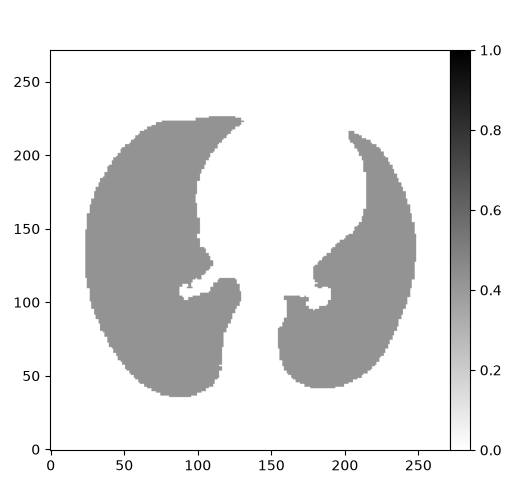

In [39]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(nu_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1))
plt.colorbar(im, cax)

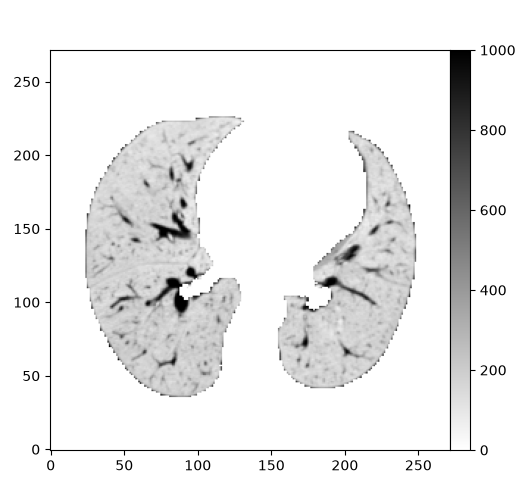

In [43]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(rho_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1000))
plt.colorbar(im, cax)

In [40]:
mesh

<meshio mesh object>
  Number of points: 32008
  Number of cells:
    tetra: 142299
  Point data: medit:ref, image, u_reg, E, nu, rho, u_fwd
  Cell data: medit:ref, region, image, u_reg, E, nu, rho, u_fwd

In [41]:
np.unique(mesh.cell_data['region'])

array([1, 2, 3, 4, 5])

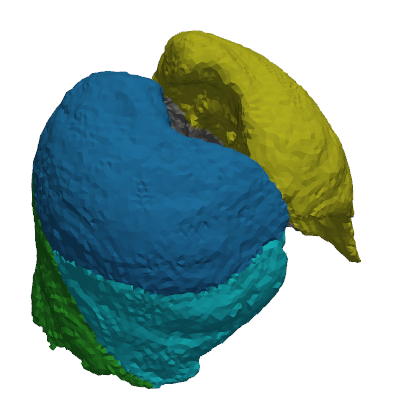

In [137]:
def show_mesh(mesh):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, scalars='region', show_scalar_bar=False, clim=(1, 5), opacity=1.0, cmap=mpl_viz.get_label_cmap(5, include_bg=False))
    #g = m.glyph(scale=key, orient=key, factor=1.0)
    #p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.4)
    p.show(jupyter_backend='static')

show_mesh(mesh)

In [158]:
vmax = np.percentile(np.linalg.norm(mesh.point_data['u_reg'], axis=1), 99)
vmax

np.float32(28.082287)

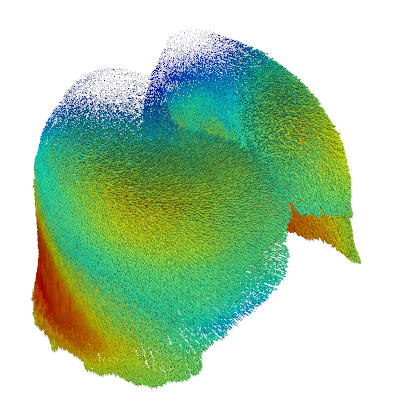

In [192]:
def plot_disp(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    #p.add_mesh(m, scalars=key, show_scalar_bar=False)
    g = m.glyph(scale=key, orient=key, factor=0.5)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet', clim=(0, vmax))
    p.camera.zoom(1.4)
    return p

p = plot_disp(mesh, key='u_reg')
p.show(jupyter_backend='static')

In [193]:
import pyvista as pv
surf = pv.wrap(mesh).extract_surface(algorithm='geometry')

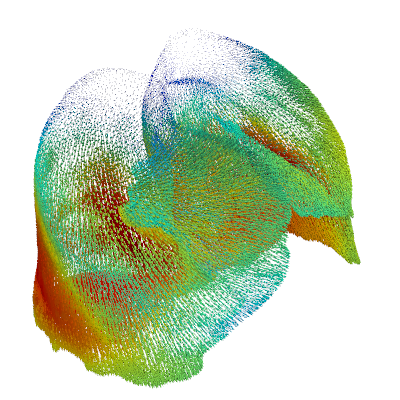

In [194]:
p = plot_disp(surf, key='u_reg')
p.show(jupyter_backend='static')

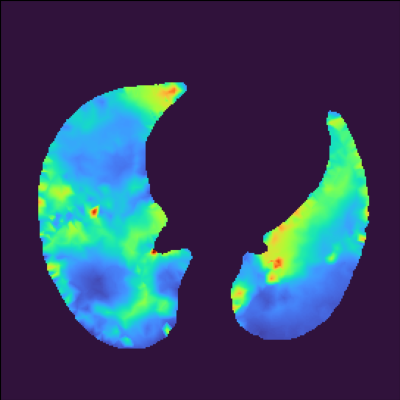

In [130]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(K_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 20000))

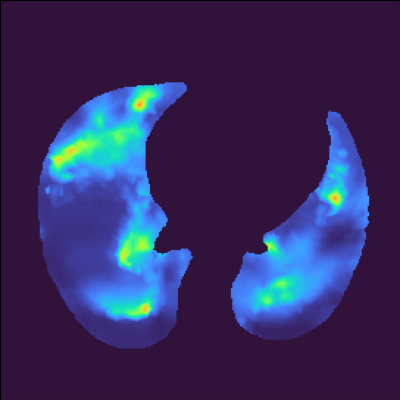

In [132]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(G_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 10000))

In [133]:
mesh = project.core.fileio.load_meshio('outputs/opt_linear/16514P/meshes/optimized.xdmf')
mesh

Loading outputs/opt_linear/16514P/meshes/optimized.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual
  Cell data: medit:ref, region, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual

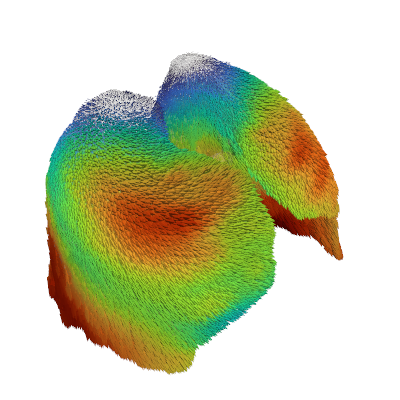

In [161]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.25)
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

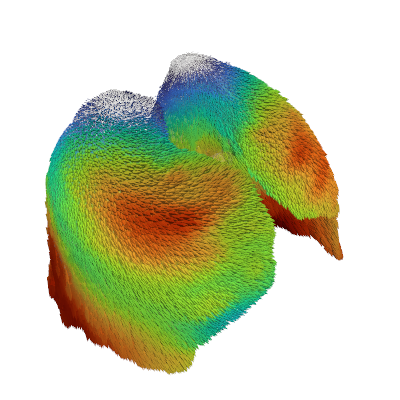

In [162]:
show_mesh(mesh, key='u_pred')

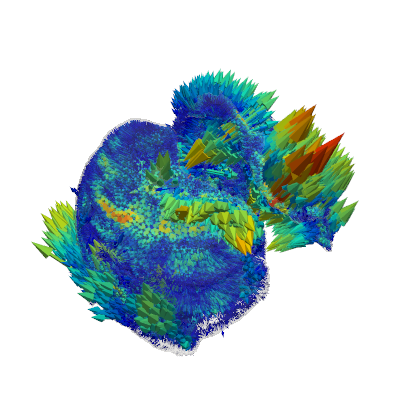

In [142]:
show_mesh(mesh, key='residual')